# 01 - Exploratory Data Analysis (EDA)

Mục tiêu: hiểu dữ liệu và các pattern liên quan đến `Late_delivery_risk` **không dùng leakage features**.

## SECTION 1: Setup & Load Data

In [35]:
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Global chart style ──────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')

PALETTE = ['#90CAF9', '#EF9A9A', '#A5D6A7', '#FFCC80', '#CE93D8', '#80DEEA']
C_BLUE, C_RED, C_GREEN, C_ORANGE, C_PURPLE, C_TEAL = PALETTE

sns.set_palette(PALETTE)
plt.rcParams.update({
    'figure.dpi':        120,
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'axes.labelsize':    11,
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
    'axes.spines.top':   False,
    'axes.spines.right': False,
})
# ────────────────────────────────────────────────────────────────────

TARGET = 'Late_delivery_risk'

candidate_paths = [
    Path('dataset/DataCoSupplyChainDataset.csv'),
    Path('../dataset/DataCoSupplyChainDataset.csv'),
]
DATA_PATH = next((p for p in candidate_paths if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError('Cannot find DataCoSupplyChainDataset.csv from current working directory.')

print(f'Using dataset path: {DATA_PATH.resolve()}')

try:
    df = pd.read_csv(DATA_PATH, encoding='cp1252')
except UnicodeDecodeError:
    df = pd.read_csv(DATA_PATH)

print(f'Shape: {df.shape}')
print()
print('Missing values (top 5):')
print(df.isnull().sum().sort_values(ascending=False).head())
print()
print('Target distribution:')
print(df[TARGET].value_counts(normalize=True).round(4))

Using dataset path: /Users/nguyentran0703/Downloads/AIO_Conquer_warm_up_02/dataset/DataCoSupplyChainDataset.csv
Shape: (180519, 53)

Missing values (top 5):
Product Description    180519
Order Zipcode          155679
Customer Lname              8
Customer Zipcode            3
Type                        0
dtype: int64

Target distribution:
Late_delivery_risk
1    0.5483
0    0.4517
Name: proportion, dtype: float64


## SECTION 2: Target Distribution

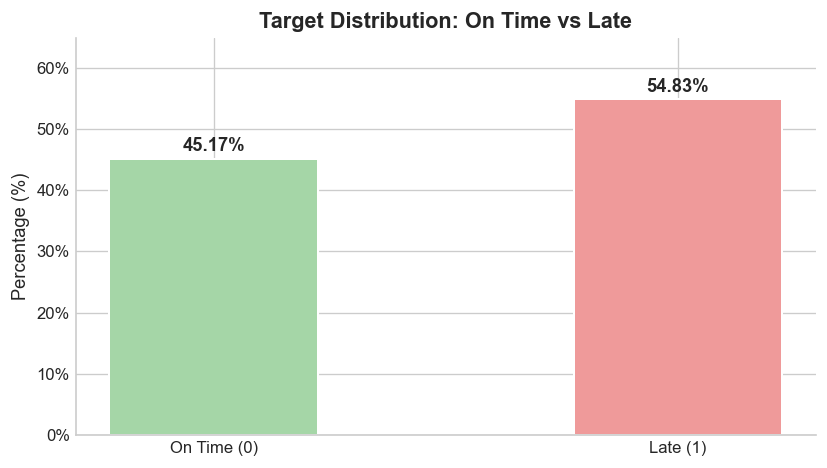

Late class ratio: 54.83%


In [36]:
target_ratio = df[TARGET].value_counts(normalize=True).sort_index() * 100
labels = ['On Time (0)', 'Late (1)']
values = [target_ratio.get(0, 0), target_ratio.get(1, 0)]
colors = [C_GREEN, C_RED]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, values, color=colors, width=0.45, edgecolor='white', linewidth=1.2)

for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.5, f'{h:.2f}%',
            ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_title('Target Distribution: On Time vs Late')
ax.set_ylabel('Percentage (%)')
ax.set_ylim(0, max(values) + 10)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%g%%'))
plt.tight_layout()
plt.show()

print(f"Late class ratio: {target_ratio.get(1, 0):.2f}%")

## SECTION 3: Shipping Mode Analysis

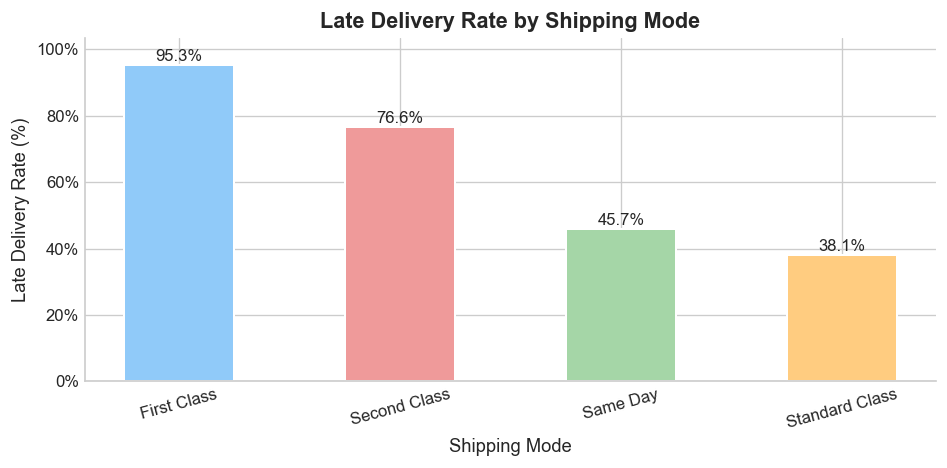

Highest-risk mode: First Class (95.32%)
Lowest-risk mode:  Standard Class (38.07%)


In [37]:
shipping_late_rate = (
    df.groupby('Shipping Mode')[TARGET]
    .mean()
    .sort_values(ascending=False)
    * 100
)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(
    shipping_late_rate.index,
    shipping_late_rate.values,
    color=PALETTE[:len(shipping_late_rate)],
    edgecolor='white', linewidth=1.2, width=0.5,
)

for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.3, f'{h:.1f}%',
            ha='center', va='bottom', fontsize=10)

ax.set_title('Late Delivery Rate by Shipping Mode')
ax.set_xlabel('Shipping Mode')
ax.set_ylabel('Late Delivery Rate (%)')
ax.set_ylim(0, max(shipping_late_rate.values) + 8)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%g%%'))
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print(f'Highest-risk mode: {shipping_late_rate.index[0]} ({shipping_late_rate.iloc[0]:.2f}%)')
print(f'Lowest-risk mode:  {shipping_late_rate.index[-1]} ({shipping_late_rate.iloc[-1]:.2f}%)')

## SECTION 4: Geographic Analysis

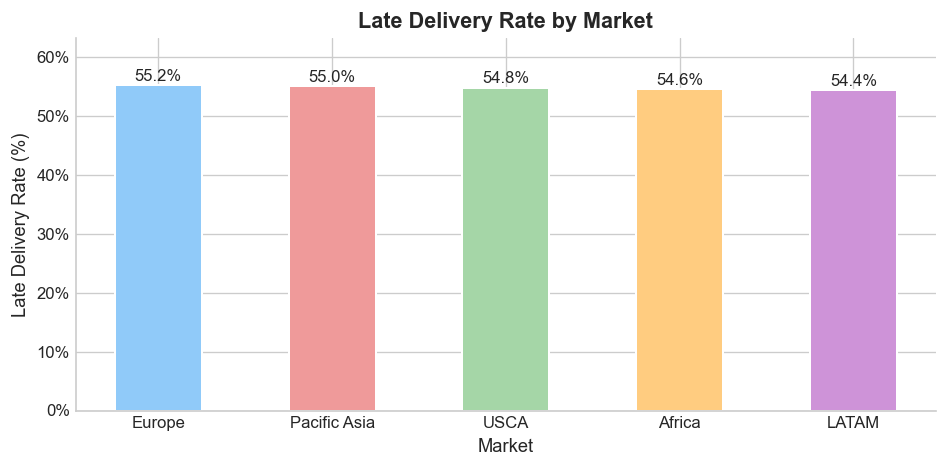

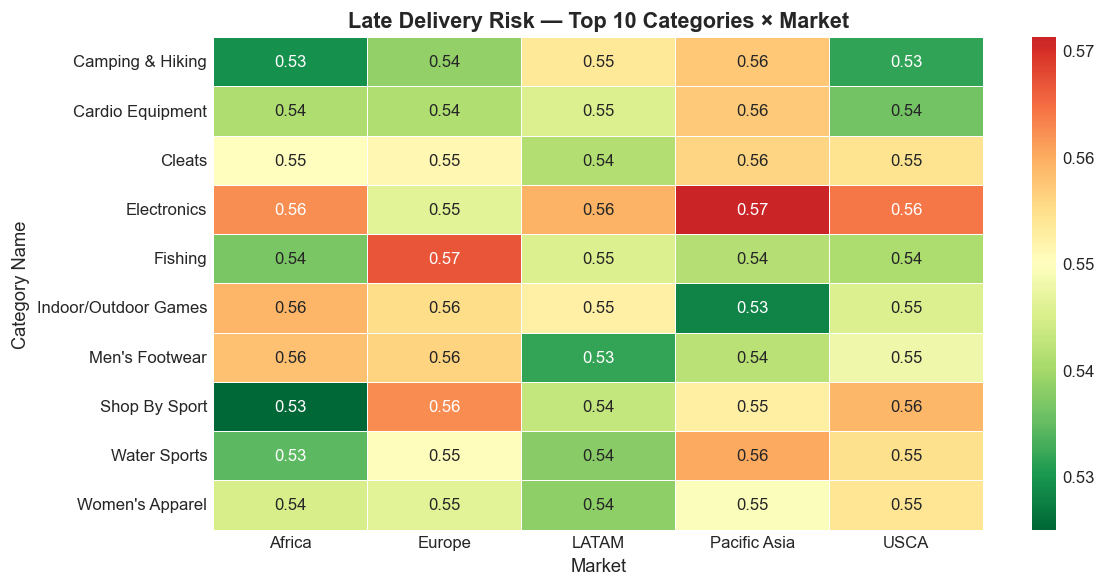

In [38]:
market_late_rate = df.groupby('Market')[TARGET].mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(
    market_late_rate.index,
    market_late_rate.values,
    color=PALETTE[:len(market_late_rate)],
    edgecolor='white', linewidth=1.2, width=0.5,
)
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.2, f'{h:.1f}%',
            ha='center', va='bottom', fontsize=10)

ax.set_title('Late Delivery Rate by Market')
ax.set_xlabel('Market')
ax.set_ylabel('Late Delivery Rate (%)')
ax.set_ylim(0, max(market_late_rate.values) + 8)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%g%%'))
plt.tight_layout()
plt.show()

# Heatmap: Top 10 Categories x Market
top_categories = df['Category Name'].value_counts().head(10).index
heat_df = df[df['Category Name'].isin(top_categories)].copy()

pivot_table = heat_df.pivot_table(
    index='Category Name',
    columns='Market',
    values=TARGET,
    aggfunc='mean'
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    pivot_table, annot=True, fmt='.2f',
    cmap='RdYlGn_r', center=0.55,
    linewidths=0.5, linecolor='white',
    ax=ax,
)
ax.set_title('Late Delivery Risk — Top 10 Categories × Market')
ax.set_xlabel('Market')
ax.set_ylabel('Category Name')
plt.tight_layout()
plt.show()

## SECTION 5: Time Analysis

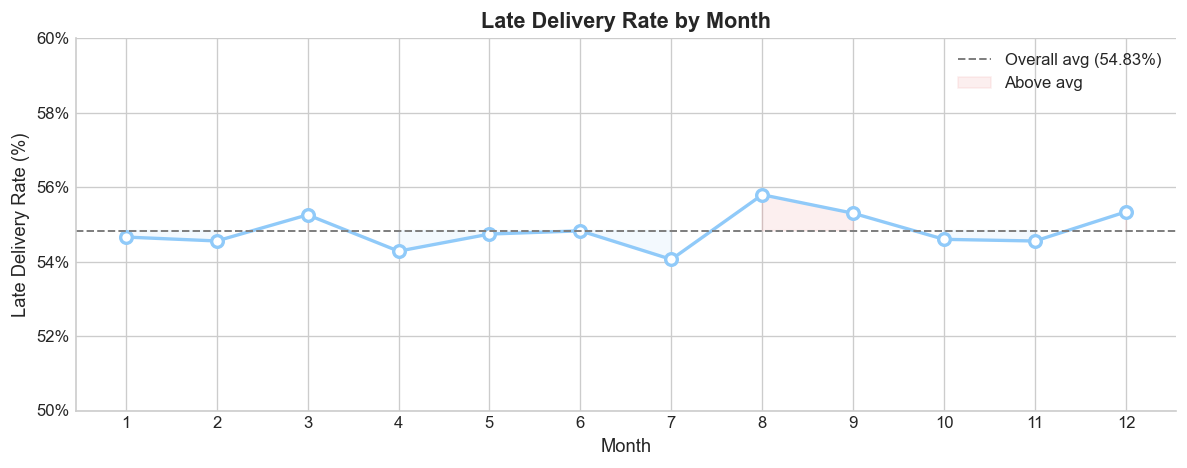

Late rate by month:
  Month  1: 54.66%
  Month  2: 54.55%
  Month  3: 55.25% ← above avg
  Month  4: 54.28%
  Month  5: 54.74%
  Month  6: 54.83%
  Month  7: 54.06%
  Month  8: 55.79% ← above avg
  Month  9: 55.30% ← above avg
  Month 10: 54.60%
  Month 11: 54.55%
  Month 12: 55.34% ← above avg

Note: Oct-Dec (months 10-12) do NOT show elevated late rates in this dataset.
Months above average: [3, 8, 9, 12]


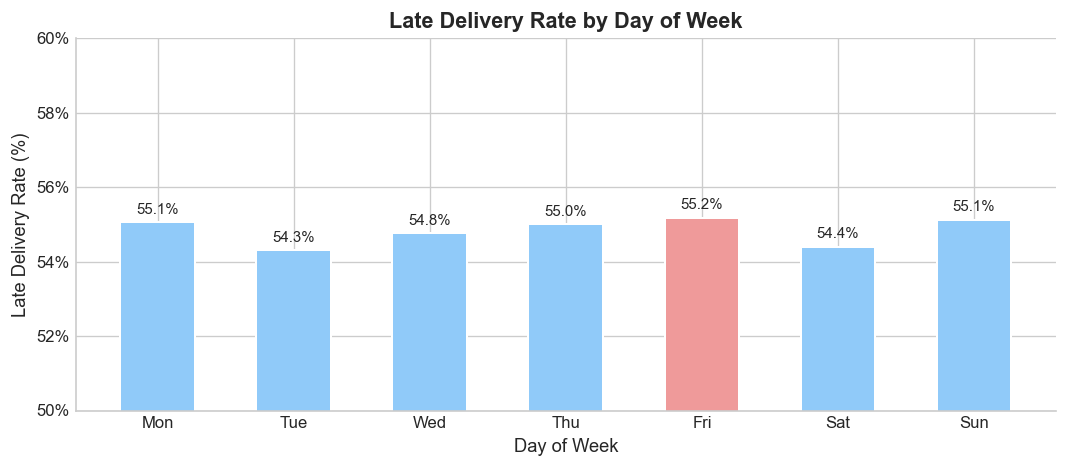

In [39]:
df['order_date_parsed'] = pd.to_datetime(df['order date (DateOrders)'], errors='coerce')
df['Month'] = df['order_date_parsed'].dt.month
df['Day_of_Week'] = df['order_date_parsed'].dt.dayofweek

monthly_late = df.groupby('Month')[TARGET].mean() * 100
overall_avg = df[TARGET].mean() * 100

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly_late.index, monthly_late.values, marker='o',
        color=C_BLUE, linewidth=2, markersize=7, markerfacecolor='white',
        markeredgewidth=2)
ax.axhline(y=overall_avg, color='gray', linestyle='--', linewidth=1.2,
           label=f'Overall avg ({overall_avg:.2f}%)')
ax.fill_between(monthly_late.index, monthly_late.values, overall_avg,
                where=(monthly_late.values > overall_avg),
                alpha=0.15, color=C_RED, label='Above avg')
ax.fill_between(monthly_late.index, monthly_late.values, overall_avg,
                where=(monthly_late.values <= overall_avg),
                alpha=0.10, color=C_BLUE)
ax.set_title('Late Delivery Rate by Month')
ax.set_xlabel('Month')
ax.set_ylabel('Late Delivery Rate (%)')
ax.set_xticks(range(1, 13))
ax.set_ylim(50, 60)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%g%%'))
ax.legend()
plt.tight_layout()
plt.show()

print('Late rate by month:')
for m, rate in monthly_late.items():
    marker = ' ← above avg' if rate > overall_avg else ''
    print(f'  Month {m:2d}: {rate:.2f}%{marker}')
print(f'\nNote: Oct-Dec (months 10-12) do NOT show elevated late rates in this dataset.')
print(f'Months above average: {[m for m, r in monthly_late.items() if r > overall_avg]}')

# Day of Week
dow_late = df.groupby('Day_of_Week')[TARGET].mean() * 100
dow_labels = {0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}
dow_colors = [C_RED if v == dow_late.max() else C_BLUE for v in dow_late.values]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(
    [dow_labels[i] for i in dow_late.index],
    dow_late.values,
    color=dow_colors, edgecolor='white', linewidth=1.2, width=0.55,
)
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.15, f'{h:.1f}%',
            ha='center', va='bottom', fontsize=9)

ax.set_title('Late Delivery Rate by Day of Week')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Late Delivery Rate (%)')
ax.set_ylim(50, 60)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%g%%'))
plt.tight_layout()
plt.show()

## SECTION 6: Scheduled Days vs Late Risk

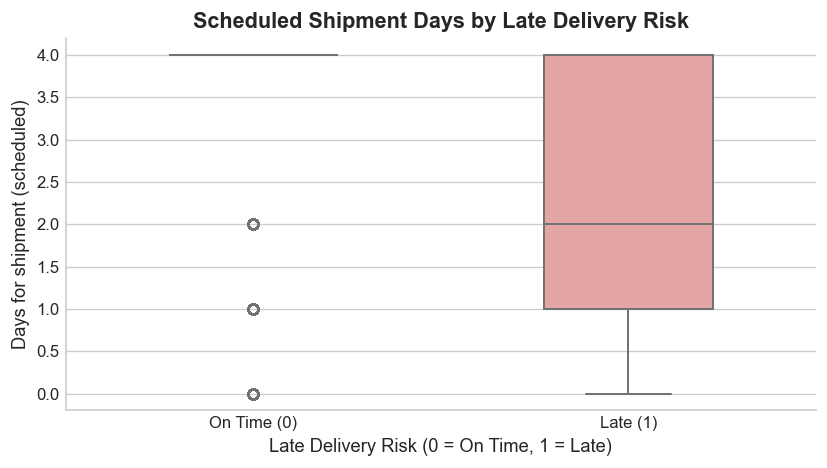

                        mean  50%       std
Late_delivery_risk                         
0                   3.491146  4.0  1.151072
1                   2.471069  2.0  1.372540


In [40]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(
    x=TARGET, y='Days for shipment (scheduled)', data=df,
    hue=TARGET,
    palette={0: C_GREEN, 1: C_RED},
    width=0.45, linewidth=1.2,
    legend=False,
    ax=ax,
)
ax.set_title('Scheduled Shipment Days by Late Delivery Risk')
ax.set_xlabel('Late Delivery Risk (0 = On Time, 1 = Late)')
ax.set_ylabel('Days for shipment (scheduled)')
ax.set_xticklabels(['On Time (0)', 'Late (1)'])
plt.tight_layout()
plt.show()

summary = df.groupby(TARGET)['Days for shipment (scheduled)'].describe()[['mean', '50%', 'std']]
print(summary)

## SECTION 7: Correlation Heatmap

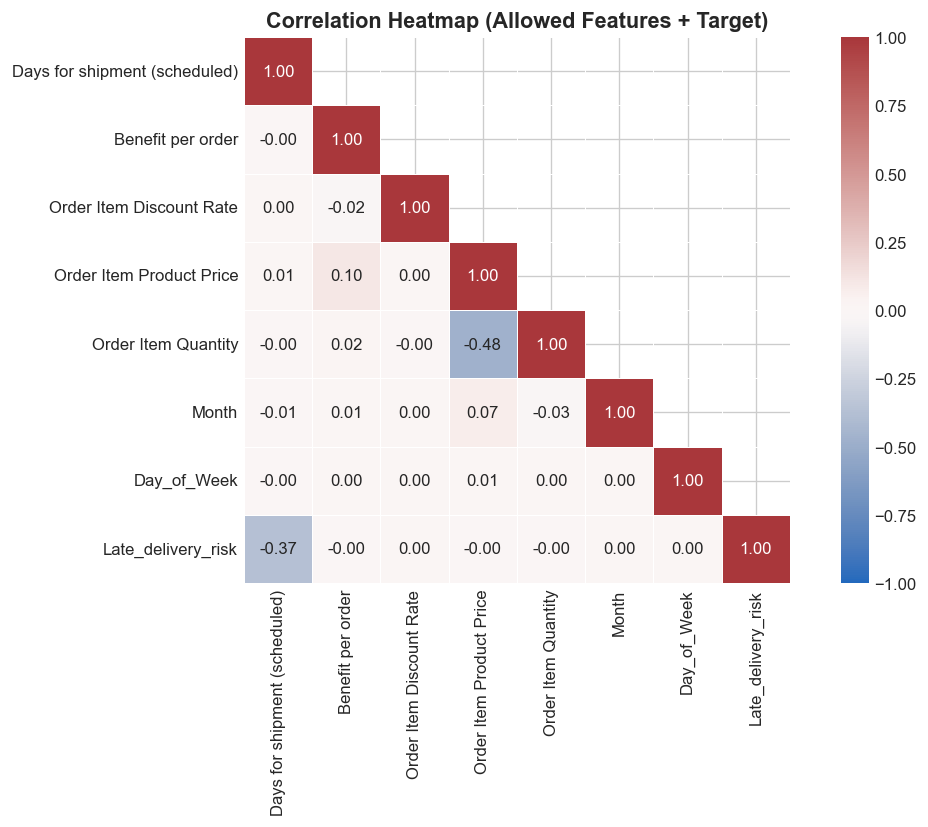

In [41]:
corr_cols = [
    'Days for shipment (scheduled)',
    'Benefit per order',
    'Order Item Discount Rate',
    'Order Item Product Price',
    'Order Item Quantity',
    'Month',
    'Day_of_Week',
    TARGET,
]

corr_df = df[corr_cols].copy()
correlation_matrix = corr_df.corr(numeric_only=True)

mask = np.zeros_like(correlation_matrix, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(
    correlation_matrix,
    mask=mask,
    annot=True, fmt='.2f',
    cmap='vlag', center=0,
    vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white',
    square=True,
    ax=ax,
)
ax.set_title('Correlation Heatmap (Allowed Features + Target)')
plt.tight_layout()
plt.show()

## SECTION 8: EDA Summary

1. `Late_delivery_risk` có phân phối tương đối cân bằng nhưng nghiêng về lớp `Late` (~54.83%), nên khi train cần theo dõi Recall cho lớp 1 sát hơn Accuracy.
2. `Shipping Mode` cho thấy mức rủi ro trễ khác nhau rõ rệt giữa các nhóm, đây là feature categorical quan trọng cho mô hình phân loại.
3. Theo `Market` và ma trận `Category Name × Market`, rủi ro trễ biến thiên theo vùng và nhóm sản phẩm, gợi ý có tương tác địa lý-ngành hàng.
4. Yếu tố thời gian (Month/Day of Week) có biến động nhẹ theo chu kỳ, nhưng **không có seasonality rõ ràng theo tháng** — late rate dao động đồng đều ~54–56% quanh năm. Oct-Dec không phải peak season trong dataset này (dataset B2B supply chain, không phải B2C retail). Feature `Is_Peak_Season` được giữ lại trong pipeline nhưng có importance rất thấp (rank 13/13).
5. Các biến số lượng như `Days for shipment (scheduled)`, `Benefit per order`, `Order Item Discount Rate` có tương quan với target, phù hợp để đưa vào pipeline modeling kế tiếp.